# SNN for Spiking Heidelberg Digits (SHD): Initial Exploration

**Goal**: Get a basic SNN working on the SHD dataset using surrogate gradient descent

Starting with single feed-forward LIF layer
Need to figure out the right time constants first 

**Paper**: Cramer et al. (2020), Table 1:
| Architecture | SHD Test Accuracy |
|---|---|
| 1-Layer Feed-Forward | ~48% |
| RSNN 128 | 71.4% |
| RSNN Best Effort | 83.2% |
| LSTM | 89.0% |

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import h5py
import time
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 1. Load the SHD Dataset

In [2]:
DATA_DIR = "/kaggle/input/datasets/harshita879/shd-snns-dataset"
train_path = os.path.join(DATA_DIR, "shd_train.h5")
test_path = os.path.join(DATA_DIR, "shd_test.h5")

print("Dataset files:")
for f in [train_path, test_path]:
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {f}: {size_mb:.1f} MB")

Dataset files:
  /kaggle/input/datasets/harshita879/shd-snns-dataset/shd_train.h5: 268.8 MB
  /kaggle/input/datasets/harshita879/shd-snns-dataset/shd_test.h5: 78.7 MB


In [3]:
with h5py.File(train_path, 'r') as f:
    print("=== HDF5 Structure ===")
    def print_structure(name, obj):
        print(f"  {name}: {type(obj).__name__}", end="")
        if hasattr(obj, 'shape'):
            print(f" shape={obj.shape} dtype={obj.dtype}")
        else:
            print()
    f.visititems(print_structure)

    n_train = len(f['labels'])
    labels = f['labels'][:]
    print(f"\nSamples: {n_train}, Classes: {len(np.unique(labels))}")

    n_spikes = [len(f['spikes/times'][i]) for i in range(min(100, n_train))]
    max_unit = max(int(f['spikes/units'][i].max()) for i in range(min(100, n_train)) if len(f['spikes/units'][i]) > 0)
    print(f"Spikes per sample: {np.mean(n_spikes):.0f} +/- {np.std(n_spikes):.0f}")
    print(f"Max unit index: {max_unit} => {max_unit+1} input channels")

=== HDF5 Structure ===
  extra: Group
  extra/keys: Dataset shape=(20,) dtype=|S6
  extra/meta_info: Group
  extra/meta_info/age: Dataset shape=(12,) dtype=uint16
  extra/meta_info/body_height: Dataset shape=(12,) dtype=uint16
  extra/meta_info/gender: Dataset shape=(12,) dtype=|S6
  extra/speaker: Dataset shape=(8156,) dtype=uint16
  labels: Dataset shape=(8156,) dtype=uint16
  spikes: Group
  spikes/times: Dataset shape=(8156,) dtype=object
  spikes/units: Dataset shape=(8156,) dtype=object

Samples: 8156, Classes: 20
Spikes per sample: 8122 +/- 2585
Max unit index: 699 => 700 input channels


## 2. Dataset & Spike Binning

Bin spikes into a [time_bins x channels] tensor. Using the paper's parameters:
- Duration: 1.0s, dt=10ms -> 100 time bins
- 700 bushy cell channels 

In [4]:
class SHDDataset(Dataset):
    def __init__(self, h5_path, n_time_bins=100, n_channels=700, max_time=1.0):
        self.n_time_bins = n_time_bins
        self.n_channels = n_channels
        self.dt = max_time / n_time_bins

        with h5py.File(h5_path, 'r') as f:
            self.labels = f['labels'][:].astype(np.int64)
            self.spike_times = []
            self.spike_units = []
            for i in range(len(self.labels)):
                self.spike_times.append(f['spikes/times'][i].astype(np.float32))
                self.spike_units.append(f['spikes/units'][i].astype(np.int32))

        self.n_classes = len(np.unique(self.labels))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        times = self.spike_times[idx]
        units = self.spike_units[idx]

        spike_tensor = np.zeros((self.n_time_bins, self.n_channels), dtype=np.float32)
        for t, u in zip(times, units):
            time_bin = int(t / self.dt)
            if 0 <= time_bin < self.n_time_bins and 0 <= u < self.n_channels:
                spike_tensor[time_bin, u] += 1.0

        return torch.tensor(spike_tensor), torch.tensor(self.labels[idx], dtype=torch.long)


train_ds = SHDDataset(train_path)
test_ds = SHDDataset(test_path)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False,
                         num_workers=2, pin_memory=True)
n_classes = train_ds.n_classes

print(f"Train: {len(train_ds)} samples, {len(train_loader)} batches")
print(f"Test:  {len(test_ds)} samples, {len(test_loader)} batches")
print(f"Input shape: [{train_ds.n_time_bins}, {train_ds.n_channels}], Classes: {n_classes}")

x_sample, y_sample = next(iter(train_loader))
print(f"\nBatch shape: {x_sample.shape}, Spikes per sample: {x_sample[0].sum():.0f}")

Train: 8156 samples, 31 batches
Test:  2264 samples, 9 batches
Input shape: [100, 700], Classes: 20

Batch shape: torch.Size([256, 100, 700]), Spikes per sample: 8663


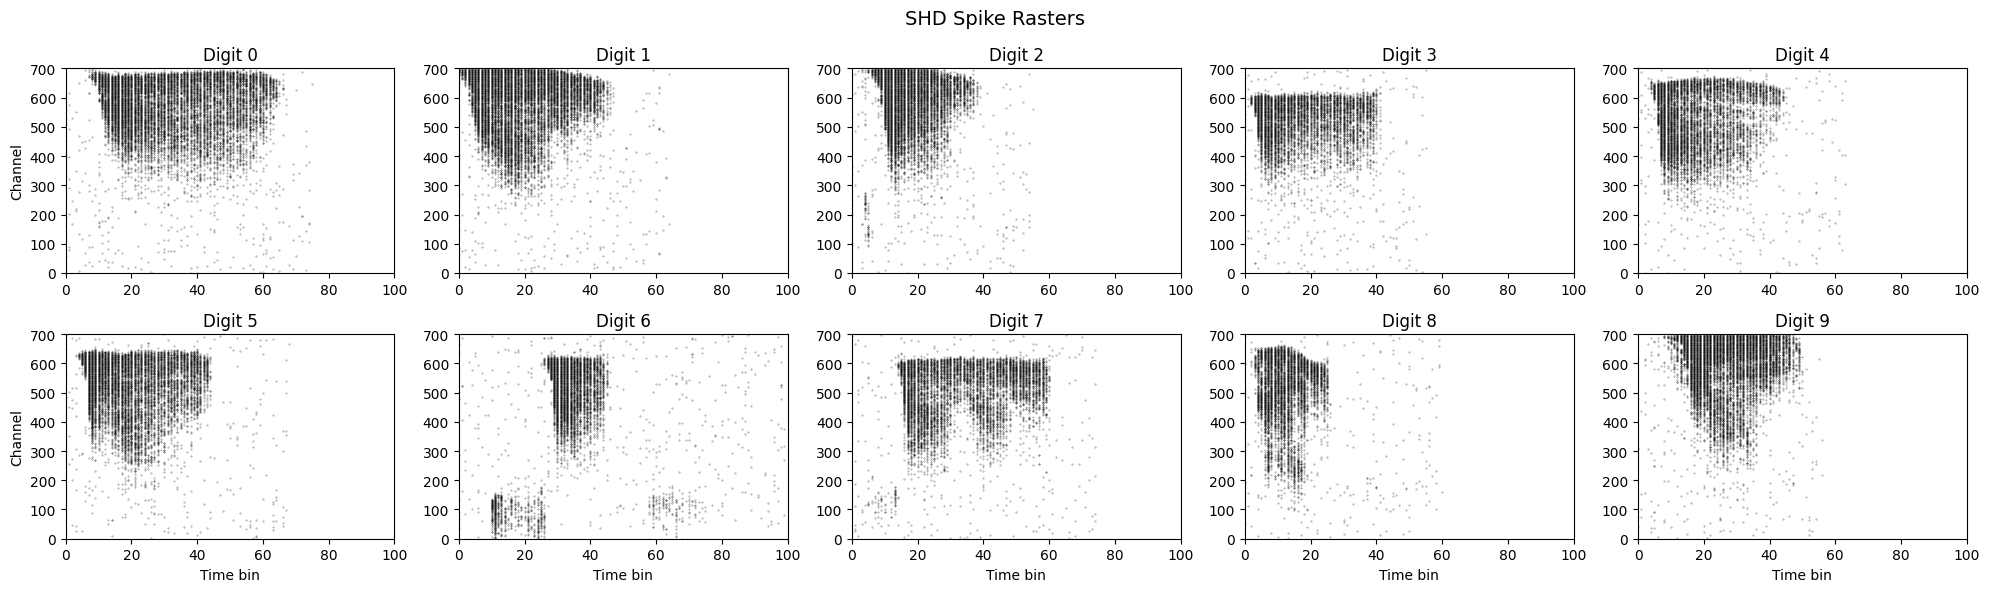

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
shown = set()
for x_batch, y_batch in train_loader:
    for i in range(len(y_batch)):
        cls = y_batch[i].item()
        if cls < 10 and cls not in shown:
            ax = axes[cls // 5, cls % 5]
            spike_t, spike_u = np.where(x_batch[i].numpy() > 0)
            ax.scatter(spike_t, spike_u, s=0.1, c='black', alpha=0.5)
            ax.set_title(f"Digit {cls}")
            ax.set_xlim(0, 100); ax.set_ylim(0, 700)
            if cls % 5 == 0: ax.set_ylabel("Channel")
            if cls >= 5: ax.set_xlabel("Time bin")
            shown.add(cls)
    if len(shown) >= 10: break
plt.suptitle("SHD Spike Rasters", fontsize=14)
plt.tight_layout()
plt.show()

## 3. SNN Components

Surrogate gradient: fast sigmoid (Cramer et al. Eq. 8) with beta=40.
LIF dynamics: Eqs. 5-6, current-based synapses.



In [6]:
class SurrogateSpike(torch.autograd.Function):
    @staticmethod
    def forward(ctx, membrane_potential, threshold=1.0):
        ctx.save_for_backward(membrane_potential)
        ctx.threshold = threshold
        return (membrane_potential >= threshold).float()

    @staticmethod
    def backward(ctx, grad_output):
        membrane_potential, = ctx.saved_tensors
        beta = SurrogateSpike.beta
        v = membrane_potential - ctx.threshold
        grad = 1.0 / (1.0 + beta * torch.abs(v)) ** 2
        return grad_output * grad, None

SurrogateSpike.beta = 40.0

def spike_fn(x, threshold=1.0):
    return SurrogateSpike.apply(x, threshold)

# sanity check
test_u = torch.randn(5, requires_grad=True)
spikes = spike_fn(test_u)
spikes.sum().backward()
print(f"Membrane: {test_u.data.numpy().round(3)}")
print(f"Spikes:   {spikes.data.numpy()}")
print(f"Grads:    {test_u.grad.numpy().round(4)}")
print("Surrogate gradient OK")

Membrane: [-1.123 -0.186  2.208 -0.638  0.462]
Spikes:   [0. 0. 1. 0. 0.]
Grads:    [0.0001 0.0004 0.0004 0.0002 0.002 ]
Surrogate gradient OK


In [7]:
class LIFLayer(nn.Module):
    """Feed-forward LIF layer. No recurrence."""
    def __init__(self, input_size, hidden_size, tau_mem=20.0, tau_syn=10.0, dt=10.0):
        super().__init__()
        self.hidden_size = hidden_size
        self.dt = dt

        self.W = nn.Linear(input_size, hidden_size, bias=False)
        self.register_buffer('log_tau_mem', torch.tensor(np.log(tau_mem)))
        self.register_buffer('log_tau_syn', torch.tensor(np.log(tau_syn)))
        nn.init.kaiming_uniform_(self.W.weight, nonlinearity='linear')

    @property
    def alpha(self):  # synaptic decay
        return torch.exp(-self.dt / torch.exp(self.log_tau_syn))

    @property
    def beta(self):  # membrane decay
        return torch.exp(-self.dt / torch.exp(self.log_tau_mem))

    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        alpha = self.alpha
        beta = self.beta

        syn = torch.zeros(batch_size, self.hidden_size, device=x.device)
        mem = torch.zeros(batch_size, self.hidden_size, device=x.device)
        prev_spk = torch.zeros(batch_size, self.hidden_size, device=x.device)

        spike_rec, mem_rec = [], []
        for t in range(n_steps):
            syn = alpha * syn + self.W(x[:, t, :])
            mem = beta * mem * (1.0 - prev_spk) + (1.0 - beta) * syn
            spk = spike_fn(mem, threshold=1.0)
            spike_rec.append(spk)
            mem_rec.append(mem)
            prev_spk = spk

        return torch.stack(spike_rec, dim=1), torch.stack(mem_rec, dim=1)


class ReadoutLayer(nn.Module):
    """Leaky integrator readout (no spiking)."""
    def __init__(self, input_size, output_size, tau_mem=20.0, dt=10.0):
        super().__init__()
        self.fc = nn.Linear(input_size, output_size, bias=False)
        self.beta = np.exp(-dt / tau_mem)
        nn.init.kaiming_uniform_(self.fc.weight, nonlinearity='linear')

    def forward(self, x):
        batch_size, n_steps, _ = x.shape
        mem = torch.zeros(batch_size, self.fc.out_features, device=x.device)
        mem_rec = []
        for t in range(n_steps):
            mem = self.beta * mem + (1 - self.beta) * self.fc(x[:, t, :])
            mem_rec.append(mem)
        return torch.stack(mem_rec, dim=1)


class SimpleSNN(nn.Module):
    """1 hidden LIF layer + readout. Max-over-time output."""
    def __init__(self, input_size, hidden_size, output_size,
                 tau_mem=20.0, tau_syn=10.0, dt=10.0):
        super().__init__()
        self.lif = LIFLayer(input_size, hidden_size, tau_mem, tau_syn, dt)
        self.readout = ReadoutLayer(hidden_size, output_size, tau_mem, dt)

    def forward(self, x):
        spikes, _ = self.lif(x)
        out_mem = self.readout(spikes)
        output, _ = torch.max(out_mem, dim=1)
        return output, [spikes], out_mem

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# check
_m = SimpleSNN(700, 128, 20).to(device)
_x = torch.randn(4, 100, 700).to(device)
_o, _s, _ = _m(_x)
print(f"SimpleSNN: {_m.count_params():,} params")
print(f"Output: {_o.shape}, Spike rate: {_s[0].mean():.4f}")
del _m, _x, _o, _s

SimpleSNN: 92,160 params
Output: torch.Size([4, 20]), Spike rate: 0.0357


## 4. Training Loop

Plain CrossEntropy + Adam

In [8]:
def train_and_eval(model, train_loader, test_loader, n_epochs=30, lr=1e-3,
                   device='cuda', title=""):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    hist = {'train_acc': [], 'test_acc': [], 'spike_rate': [], 'train_loss': []}
    best_acc = 0

    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        spike_rates = []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits, all_spikes, _ = model(x)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
            epoch_loss += loss.item() * len(y)
            spike_rates.append(all_spikes[0].detach().mean().item())

        train_acc = correct / total
        mean_spk = np.mean(spike_rates)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits, _, _ = model(x)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)
        hist['spike_rate'].append(mean_spk)
        hist['train_loss'].append(epoch_loss / total)
        elapsed = time.time() - t0

        if epoch % 5 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:3d}/{n_epochs} | Train: {train_acc:.4f} ({epoch_loss/total:.4f}) | "
                  f"Test: {test_acc:.4f} | Spk: {mean_spk:.4f} | Best: {best_acc:.4f} | {elapsed:.1f}s")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(hist['train_acc'], label='Train', alpha=0.8)
    axes[0].plot(hist['test_acc'], label='Test', alpha=0.8)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['train_loss'], alpha=0.8, color='orange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{title} — Loss'); axes[1].grid(True, alpha=0.3)
    axes[2].plot(hist['spike_rate'], color='green', alpha=0.8)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Mean Spike Rate')
    axes[2].set_title(f'{title} — Spike Activity'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return best_acc, hist

print("Training function ready")

Training function ready


## 5. Experiment 1: tau_mem = 5ms (fast decay)

Short membrane time constant. With dt=10ms:
- beta = exp(-10/5) = 0.135 -> membrane loses 86.5% each step
- Neurons need massive input in a single step to reach threshold



EXPERIMENT 1: tau_mem=5ms, tau_syn=5ms (no regularisation)
  Decay: alpha=0.1353, beta=0.1353
  Membrane retains 13.5% per step

Params: 92,160
Epoch   0/30 | Train: 0.0990 (10.3075) | Test: 0.1475 | Spk: 0.0378 | Best: 0.1475 | 37.8s
Epoch   5/30 | Train: 0.2600 (8.4544) | Test: 0.2398 | Spk: 0.0669 | Best: 0.2398 | 38.0s
Epoch  10/30 | Train: 0.3463 (7.5223) | Test: 0.3167 | Spk: 0.0798 | Best: 0.3167 | 38.0s
Epoch  15/30 | Train: 0.4062 (6.7443) | Test: 0.3255 | Spk: 0.0862 | Best: 0.3255 | 37.5s
Epoch  20/30 | Train: 0.4628 (6.2334) | Test: 0.3260 | Spk: 0.0946 | Best: 0.3445 | 37.6s
Epoch  25/30 | Train: 0.5127 (5.6683) | Test: 0.3631 | Spk: 0.0959 | Best: 0.3631 | 37.8s
Epoch  29/30 | Train: 0.5349 (5.3294) | Test: 0.3644 | Spk: 0.0980 | Best: 0.3644 | 38.1s


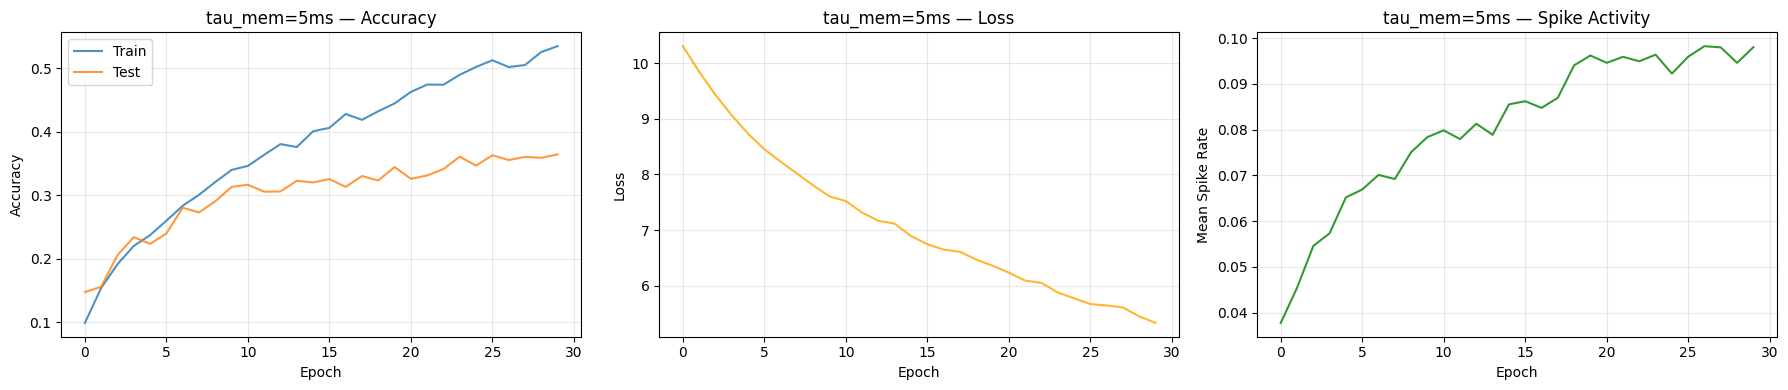


Best test: 36.44%
Final spike rate: 0.0980


In [9]:
print("=" * 60)
print("EXPERIMENT 1: tau_mem=5ms, tau_syn=5ms (no regularisation)")
print("=" * 60)
print(f"  Decay: alpha={np.exp(-10/5):.4f}, beta={np.exp(-10/5):.4f}")
print(f"  Membrane retains {np.exp(-10/5)*100:.1f}% per step")
print()

model_fast = SimpleSNN(input_size=700, hidden_size=128, output_size=n_classes,
                       tau_mem=5.0, tau_syn=5.0, dt=10.0)
print(f"Params: {model_fast.count_params():,}")

acc_fast, hist_fast = train_and_eval(
    model_fast, train_loader, test_loader,
    n_epochs=30, lr=1e-3, device=device, title="tau_mem=5ms"
)
print(f"\nBest test: {acc_fast*100:.2f}%")
print(f"Final spike rate: {hist_fast['spike_rate'][-1]:.4f}")
if hist_fast['spike_rate'][-1] < 0.005:
    print(">>> Barely any spikes — neurons are essentially dead")

## 6. Experiment 2: tau_mem = 100ms (slow decay)


- beta = exp(-10/100) = 0.905 -> membrane retains 90.5% each step


EXPERIMENT 2: tau_mem=100ms, tau_syn=50ms (no regularisation)
  Decay: alpha=0.8187, beta=0.9048
  Membrane retains 90.5% per step

Params: 92,160
Epoch   0/30 | Train: 0.1150 (10.2747) | Test: 0.2142 | Spk: 0.0336 | Best: 0.2142 | 38.3s
Epoch   5/30 | Train: 0.3377 (7.8642) | Test: 0.3666 | Spk: 0.0938 | Best: 0.3666 | 37.8s
Epoch  10/30 | Train: 0.4802 (6.2013) | Test: 0.4466 | Spk: 0.1195 | Best: 0.4466 | 37.8s
Epoch  15/30 | Train: 0.5591 (5.2613) | Test: 0.5027 | Spk: 0.1310 | Best: 0.5027 | 38.5s
Epoch  20/30 | Train: 0.6285 (4.5916) | Test: 0.5261 | Spk: 0.1370 | Best: 0.5261 | 37.7s
Epoch  25/30 | Train: 0.6780 (4.0968) | Test: 0.5261 | Spk: 0.1409 | Best: 0.5420 | 38.0s
Epoch  29/30 | Train: 0.7046 (3.7445) | Test: 0.5384 | Spk: 0.1454 | Best: 0.5420 | 37.4s


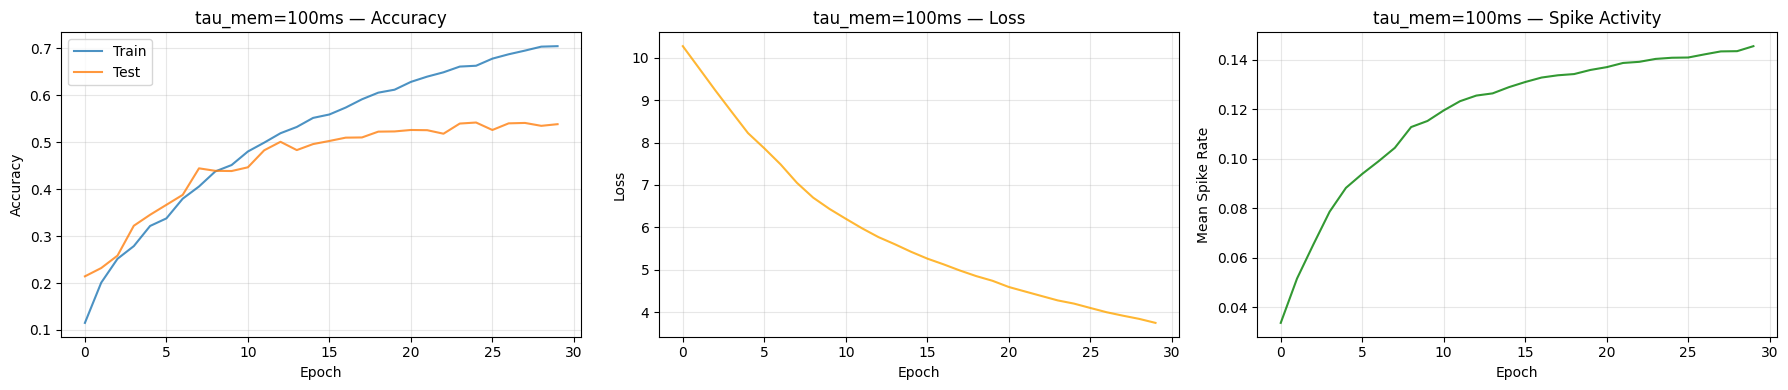


Best test: 54.20%
Final spike rate: 0.1454


In [10]:
print("=" * 60)
print("EXPERIMENT 2: tau_mem=100ms, tau_syn=50ms (no regularisation)")
print("=" * 60)
print(f"  Decay: alpha={np.exp(-10/50):.4f}, beta={np.exp(-10/100):.4f}")
print(f"  Membrane retains {np.exp(-10/100)*100:.1f}% per step")
print()

model_slow = SimpleSNN(input_size=700, hidden_size=128, output_size=n_classes,
                       tau_mem=100.0, tau_syn=50.0, dt=10.0)
print(f"Params: {model_slow.count_params():,}")

acc_slow, hist_slow = train_and_eval(
    model_slow, train_loader, test_loader,
    n_epochs=30, lr=1e-3, device=device, title="tau_mem=100ms"
)
print(f"\nBest test: {acc_slow*100:.2f}%")
print(f"Final spike rate: {hist_slow['spike_rate'][-1]:.4f}")
if hist_slow['spike_rate'][-1] > 0.3:
    print(">>> Very high firing rate — neurons saturated")

## 7. Experiment 3: Paper defaults (tau_mem=20ms, tau_syn=10ms)

From Cramer et al. Table 2
- tau_mem=20ms -> beta = exp(-0.5) = 0.607
- tau_syn=10ms -> alpha = exp(-1) = 0.368



EXPERIMENT 3: tau_mem=20ms, tau_syn=10ms (no regularisation)
  Decay: alpha=0.3679, beta=0.6065
  Membrane retains 60.7% per step

Params: 92,160
Epoch   0/50 | Train: 0.1226 (10.2629) | Test: 0.1617 | Spk: 0.0232 | Best: 0.1617 | 38.1s
Epoch   5/50 | Train: 0.3430 (7.7826) | Test: 0.3242 | Spk: 0.0622 | Best: 0.3242 | 38.6s
Epoch  10/50 | Train: 0.4365 (6.5754) | Test: 0.3246 | Spk: 0.0775 | Best: 0.3246 | 38.5s
Epoch  15/50 | Train: 0.5054 (5.7791) | Test: 0.3534 | Spk: 0.0824 | Best: 0.3666 | 37.5s
Epoch  20/50 | Train: 0.5510 (5.2241) | Test: 0.3838 | Spk: 0.0845 | Best: 0.3838 | 37.5s
Epoch  25/50 | Train: 0.5915 (4.7668) | Test: 0.3772 | Spk: 0.0860 | Best: 0.3838 | 38.0s
Epoch  30/50 | Train: 0.6295 (4.4103) | Test: 0.3719 | Spk: 0.0888 | Best: 0.3838 | 37.5s
Epoch  35/50 | Train: 0.6729 (4.0134) | Test: 0.3922 | Spk: 0.0870 | Best: 0.3931 | 37.6s
Epoch  40/50 | Train: 0.6956 (3.7457) | Test: 0.3834 | Spk: 0.0871 | Best: 0.4019 | 37.5s
Epoch  45/50 | Train: 0.7195 (3.5155) | Tes

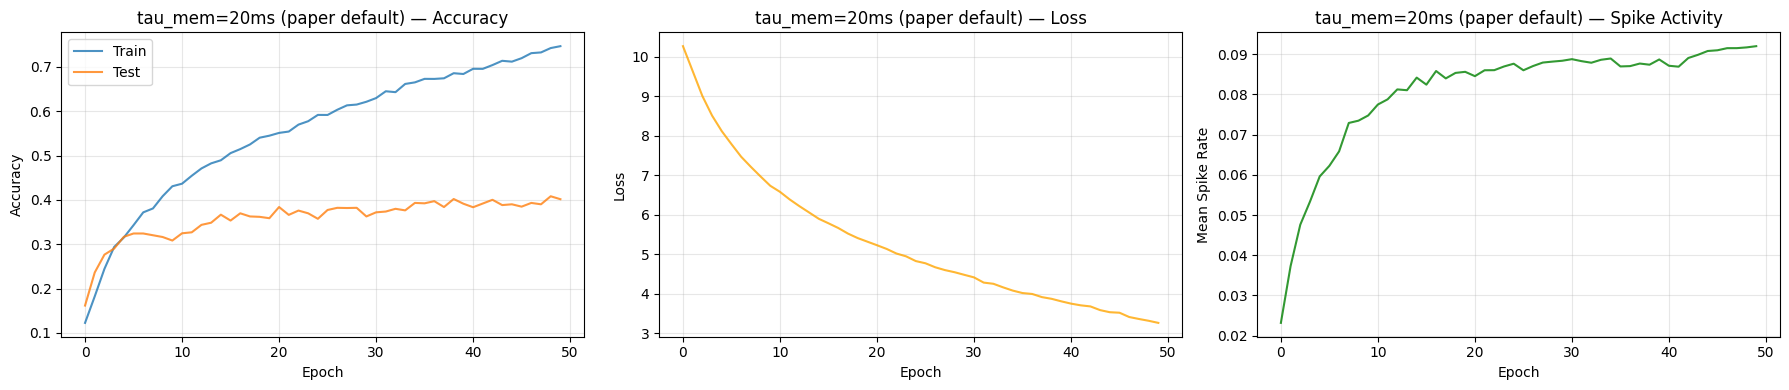


Best test: 40.81%
Final spike rate: 0.0920


In [11]:
print("=" * 60)
print("EXPERIMENT 3: tau_mem=20ms, tau_syn=10ms (no regularisation)")
print("=" * 60)
print(f"  Decay: alpha={np.exp(-1):.4f}, beta={np.exp(-0.5):.4f}")
print(f"  Membrane retains {np.exp(-0.5)*100:.1f}% per step")
print()

model_default = SimpleSNN(input_size=700, hidden_size=128, output_size=n_classes,
                          tau_mem=20.0, tau_syn=10.0, dt=10.0)
print(f"Params: {model_default.count_params():,}")

acc_default, hist_default = train_and_eval(
    model_default, train_loader, test_loader,
    n_epochs=50, lr=1e-3, device=device, title="tau_mem=20ms (paper default)"
)
print(f"\nBest test: {acc_default*100:.2f}%")
print(f"Final spike rate: {hist_default['spike_rate'][-1]:.4f}")

## 8. Experiment 4: Add spike regularisation

Firing rate regularisation from Cramer et al. Eqs. 10-11. Penalises neurons that fire too rarely (lower bound) or population that fires too much (upper bound). Also using Adamax and gradient clipping

In [12]:
def spike_regularization(all_spikes, theta_l=0.01, s_l=1.0, theta_u=100.0, s_u=0.06):
    reg_loss = torch.tensor(0.0, device=all_spikes[0].device)
    for spikes in all_spikes:
        batch_size, T, N = spikes.shape
        mean_rate = spikes.sum(dim=1) / T
        lower_violation = F.relu(theta_l - mean_rate)
        L1 = s_l / (batch_size * N) * (lower_violation ** 2).sum()
        pop_count = spikes.sum(dim=(1, 2)) / N
        upper_violation = F.relu(pop_count - theta_u)
        L2 = s_u / batch_size * (upper_violation ** 2).sum()
        reg_loss = reg_loss + L1 + L2
    return reg_loss


def train_with_reg(model, train_loader, test_loader, n_epochs=50, lr=1e-3,
                   device='cuda', title=""):
    model = model.to(device)
    optimizer = torch.optim.Adamax(model.parameters(), lr=lr, betas=(0.9, 0.999))
    criterion = nn.CrossEntropyLoss()

    hist = {'train_acc': [], 'test_acc': [], 'spike_rate': [], 'train_loss': []}
    best_acc = 0

    for epoch in range(n_epochs):
        t0 = time.time()
        model.train()
        correct, total, epoch_loss = 0, 0, 0
        spike_rates = []

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            logits, all_spikes, _ = model(x)
            cls_loss = criterion(logits, y)
            reg_loss = spike_regularization(all_spikes)
            loss = cls_loss + reg_loss

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            correct += (logits.argmax(1) == y).sum().item()
            total += len(y)
            epoch_loss += cls_loss.item() * len(y)
            spike_rates.append(all_spikes[0].detach().mean().item())

        train_acc = correct / total
        mean_spk = np.mean(spike_rates)

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(device), y.to(device)
                logits, _, _ = model(x)
                correct += (logits.argmax(1) == y).sum().item()
                total += len(y)
        test_acc = correct / total
        best_acc = max(best_acc, test_acc)

        hist['train_acc'].append(train_acc)
        hist['test_acc'].append(test_acc)
        hist['spike_rate'].append(mean_spk)
        hist['train_loss'].append(epoch_loss / total)
        elapsed = time.time() - t0

        if epoch % 5 == 0 or epoch == n_epochs - 1:
            print(f"Epoch {epoch:3d}/{n_epochs} | Train: {train_acc:.4f} ({epoch_loss/total:.4f}) | "
                  f"Test: {test_acc:.4f} | Spk: {mean_spk:.4f} | Best: {best_acc:.4f} | {elapsed:.1f}s")

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(hist['train_acc'], label='Train', alpha=0.8)
    axes[0].plot(hist['test_acc'], label='Test', alpha=0.8)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'{title} — Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist['train_loss'], alpha=0.8, color='orange')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].set_title(f'{title} — Loss'); axes[1].grid(True, alpha=0.3)
    axes[2].plot(hist['spike_rate'], color='green', alpha=0.8)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Mean Spike Rate')
    axes[2].set_title(f'{title} — Spike Activity'); axes[2].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return best_acc, hist

EXPERIMENT 4: tau_mem=20ms + spike regularisation + Adamax
Params: 92,160
Epoch   0/60 | Train: 0.1043 (10.3639) | Test: 0.1440 | Spk: 0.0203 | Best: 0.1440 | 37.6s
Epoch   5/60 | Train: 0.2714 (8.8838) | Test: 0.2778 | Spk: 0.0485 | Best: 0.2778 | 37.3s
Epoch  10/60 | Train: 0.3276 (7.9968) | Test: 0.3154 | Spk: 0.0571 | Best: 0.3229 | 37.4s
Epoch  15/60 | Train: 0.3850 (7.4042) | Test: 0.3556 | Spk: 0.0636 | Best: 0.3556 | 37.4s
Epoch  20/60 | Train: 0.4123 (6.9349) | Test: 0.3670 | Spk: 0.0673 | Best: 0.3710 | 37.7s
Epoch  25/60 | Train: 0.4531 (6.5546) | Test: 0.3958 | Spk: 0.0691 | Best: 0.3958 | 38.5s
Epoch  30/60 | Train: 0.4849 (6.2294) | Test: 0.4046 | Spk: 0.0704 | Best: 0.4086 | 37.4s
Epoch  35/60 | Train: 0.5019 (5.9712) | Test: 0.4134 | Spk: 0.0694 | Best: 0.4139 | 37.5s
Epoch  40/60 | Train: 0.5323 (5.6747) | Test: 0.4165 | Spk: 0.0716 | Best: 0.4205 | 38.6s
Epoch  45/60 | Train: 0.5565 (5.4314) | Test: 0.4192 | Spk: 0.0719 | Best: 0.4293 | 38.1s
Epoch  50/60 | Train: 0.5

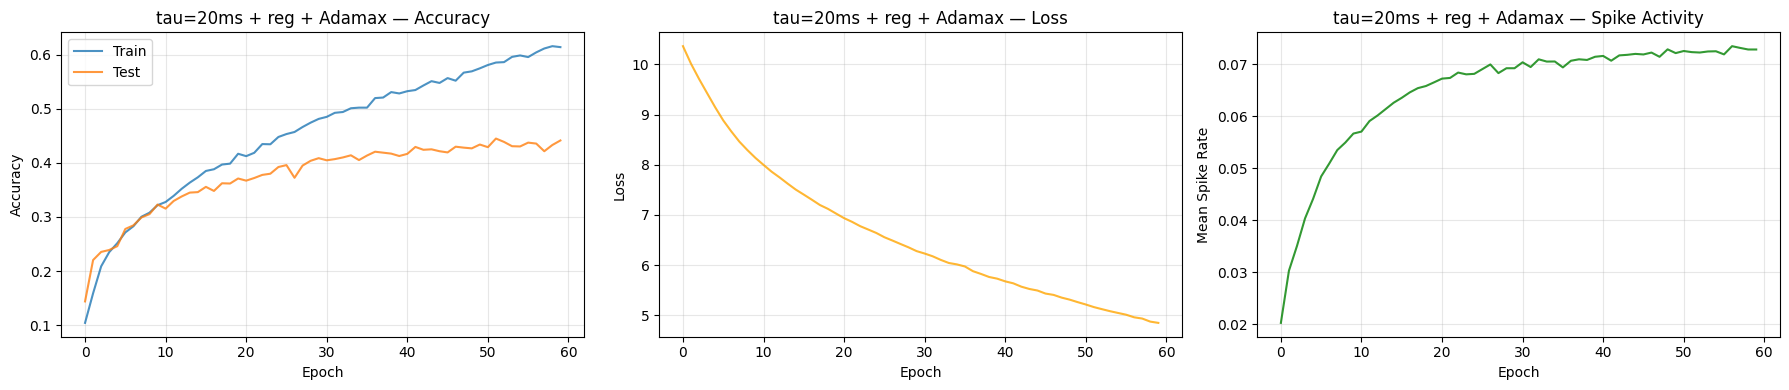


Best test: 44.48%
Final spike rate: 0.0729


In [13]:
print("=" * 60)
print("EXPERIMENT 4: tau_mem=20ms + spike regularisation + Adamax")
print("=" * 60)

model_reg = SimpleSNN(input_size=700, hidden_size=128, output_size=n_classes,
                      tau_mem=20.0, tau_syn=10.0, dt=10.0)
print(f"Params: {model_reg.count_params():,}")

acc_reg, hist_reg = train_with_reg(
    model_reg, train_loader, test_loader,
    n_epochs=60, lr=1e-3, device=device,
    title="tau=20ms + reg + Adamax"
)
print(f"\nBest test: {acc_reg*100:.2f}%")
print(f"Final spike rate: {hist_reg['spike_rate'][-1]:.4f}")

## 9. Results Summary

In [14]:
print("=" * 70)
print("RESULTS — Initial SHD Exploration")
print("=" * 70)
print(f"{'Experiment':<50} {'Test Acc':>10} {'Spike Rate':>12}")
print("-" * 72)
experiments = [
    ("1: tau_mem=5ms (no reg)", acc_fast, hist_fast['spike_rate'][-1]),
    ("2: tau_mem=100ms (no reg)", acc_slow, hist_slow['spike_rate'][-1]),
    ("3: tau_mem=20ms (no reg)", acc_default, hist_default['spike_rate'][-1]),
    ("4: tau_mem=20ms + reg + Adamax", acc_reg, hist_reg['spike_rate'][-1]),
]
for name, acc, spk in experiments:
    print(f"  {name:<48} {acc*100:>8.2f}% {spk:>10.4f}")
print("-" * 72)
print(f"  {'Random baseline (20 classes)':<48} {'5.00%':>10}")
print(f"  {'Paper: 1-layer FF (Cramer et al.)':<48} {'48.60%':>10}")
print()
print("Takeaways:")
print("  - tau=5ms: membrane decays too fast, neurons barely fire")
print("  - tau=100ms: membrane barely decays, everything fires all the time")
print("  - tau=20ms (paper values): healthy regime, actual learning")
print("  - Spike regularisation + Adamax + grad clipping pushes it further")
print()
print("Next steps: recurrence, bigger networks, data augmentation")

RESULTS — Initial SHD Exploration
Experiment                                           Test Acc   Spike Rate
------------------------------------------------------------------------
  1: tau_mem=5ms (no reg)                             36.44%     0.0980
  2: tau_mem=100ms (no reg)                           54.20%     0.1454
  3: tau_mem=20ms (no reg)                            40.81%     0.0920
  4: tau_mem=20ms + reg + Adamax                      44.48%     0.0729
------------------------------------------------------------------------
  Random baseline (20 classes)                          5.00%
  Paper: 1-layer FF (Cramer et al.)                    48.60%

Takeaways:
  - tau=5ms: membrane decays too fast, neurons barely fire
  - tau=100ms: membrane barely decays, everything fires all the time
  - tau=20ms (paper values): healthy regime, actual learning
  - Spike regularisation + Adamax + grad clipping pushes it further

Next steps: recurrence, bigger networks, data augmentation


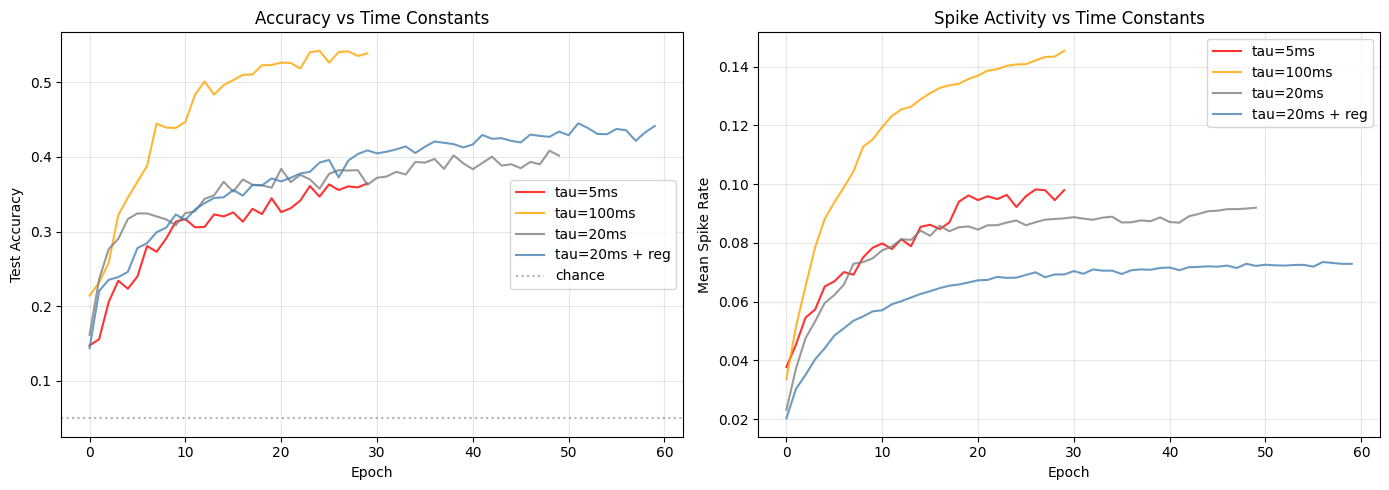

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, h, color in [
    ('tau=5ms', hist_fast, 'red'),
    ('tau=100ms', hist_slow, 'orange'),
    ('tau=20ms', hist_default, 'gray'),
    ('tau=20ms + reg', hist_reg, 'steelblue'),
]:
    axes[0].plot(h['test_acc'], label=name, alpha=0.8, color=color)
    axes[1].plot(h['spike_rate'], label=name, alpha=0.8, color=color)

axes[0].axhline(y=0.05, color='black', linestyle=':', alpha=0.3, label='chance')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Accuracy vs Time Constants'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean Spike Rate')
axes[1].set_title('Spike Activity vs Time Constants'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
save_path = '/kaggle/working/initial_snn_shd.pth'
torch.save({
    'model_state_dict': model_reg.state_dict(),
    'config': dict(input_size=700, hidden_size=128, output_size=n_classes,
                   tau_mem=20.0, tau_syn=10.0, dt=10.0),
    'best_test_acc': acc_reg,
    'results': {name: acc for name, acc, _ in experiments},
}, save_path)
print(f"Saved to {save_path}")

Saved to /kaggle/working/initial_snn_shd.pth
